In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1. Define constants

In [2]:
# Stoke's Law correction factor
b = 6.17e-6      # m(cmHg)
b_err = .01      # m(cmHg)

# voltage applied to the capacitor
V = 400.5
V_err = np.sqrt(0.8**2. + 0.16**2.)

# distance between capacitor plates
d = 4.44e-3      # m
d_err = 0.02e-3  # m

## we assume these values have no uncertainties

# accepted electron charge
e = 1.602176634e-19      # C

# gravitational acceleration in Columbus, OH
g = 9.801      # m / s^2

# Density of Nye Lubricants Watch Oil 140C
rho = 0.86e3      # kg/m^3

# Viscosity of air (at T = 20° C)
eta = 18.13e-6      # N s / m^2

# atmospheric pressure at sea level
P = 76.      # cmHg

## 2. write out derivatives for error analysis

In [41]:
def dq_dd(v_E, v_g, a):
    term1 = (6. * np.pi / V) * np.sqrt((9. * eta**3.) / (2. * rho * g))
    term2 = (v_E + v_g) * np.sqrt(v_g) * pow(1 + b / (a * P), -1.5)
    return term1 * term2

def dq_dV(v_E, v_g, a):
    term1 = 9. * np.sqrt(2.) * np.pi * d * (v_E + v_g) * np.sqrt(v_g) * np.sqrt(eta**3. / (rho * g))
    term2 = V * V * pow(1 + b / (a * P), 1.5)
    return term1 / term2

def dq_dvE(v_E, v_g, a):
    term1 = 9. * np.sqrt(2.) * np.pi * d * np.sqrt(v_g) * np.sqrt(eta**3. / (rho * g))
    term2 = V * pow(1 + b / (a * P), 1.5)
    return term1 / term2

def dq_dvg(v_E, v_g, a):
    term1 = (9. * np.pi * d / (np.sqrt(2.) * V)) * np.sqrt(eta**3. / (rho * g))
    term2 = (3. * v_g + v_E) / np.sqrt(v_g) * pow(1 + b / (a * P), -1.5)
    return term1 * term2

def dq_da(v_E, v_g, a):
    term1 = (27. * np.pi * b * d) * (v_g + v_E) * np.sqrt(eta**3. / (rho * g))
    term2 = np.sqrt(2.) * V * P * a * a * pow(1 + b / (a * P), 2.5)
    return term1 / term2

def dq_db(v_E, v_g, a):
    term1 = (-27. * np.pi * d) * np.sqrt(v_g) * (v_g + v_E) * np.sqrt(eta**3. / (rho * g))
    term2 = np.sqrt(2.) * P * V * a * pow(1 + b / (a * P), 2.5)
    return term1 / term2

In [42]:
## final error equation

def calc_err(v_E, v_g, a, vE_err, vg_err, a_err):
    d_dep = (dq_dd(v_E, v_g, a))**2. * (d_err * d_err)
    V_dep = (dq_dV(v_E, v_g, a))**2. * (V_err * V_err)
    vE_dep = (dq_dvE(v_E, v_g, a))**2. * (vE_err * vE_err)
    vg_dep = (dq_dvg(v_E, v_g, a))**2. * (vg_err * vg_err)
    a_dep = (dq_da(v_E, v_g, a))**2. * (a_err * a_err)
    b_dep = (dq_db(v_E, v_g, a))**2. * (b_err * b_err)
    
#     print(' d contribution: ', np.sqrt(d_dep), '\n V contr: ', np.sqrt(V_dep), '\n vE contr: ', np.sqrt(vE_dep))
#     print(' vg contr: ', np.sqrt(vg_dep), '\n b contr: ', np.sqrt(b_dep), '\n a contr: ', np.sqrt(a_dep), '\n')
    return np.sqrt(d_dep + V_dep + vE_dep + vg_dep + a_dep + b_dep)

### 3. Read in Data

In [5]:
import pandas as pd

In [24]:
df = pd.read_csv('drop_data.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,q,electrons,a,VG,VE,VE_err,VG_err,Particle,A_err
0,0,0,4.925807e-19,3.074786,8.266420e-07,0.070598,0.105431,0.055250,0.023085,t11_p1.csv,0.000185
1,1,1,3.301273e-19,2.060720,8.615716e-07,0.076690,0.035886,0.063626,0.017400,t11_p2.csv,0.000178
2,2,2,1.921628e-18,11.995184,1.363566e-06,0.192093,0.202423,0.086385,0.069198,\t1_p1.csv,0.000112
3,3,3,6.059680e-19,3.782572,9.235390e-07,0.088119,0.102988,0.045058,0.060184,\t1_p2.csv,0.000166
4,4,4,4.873529e-19,3.042153,8.187104e-07,0.069250,0.106827,0.044214,0.025117,\t1_p3.csv,0.000187


### 4. Calculate error for each particle

In [51]:
err_vals = np.zeros(len(df))
i=0
for row in df.itertuples():
    err_vals[i] = calc_err(row.VE, row.VG, row.a, row.VE_err, row.VG_err, row.A_err)
    i+=1
    
df['q_err'] = err_vals

In [52]:
# sort data frame by increasing charge for better plotting
new_df = df.sort_values('q')
new_df['num'] = np.arange(0,len(new_df),1)

### 5. Plot the data

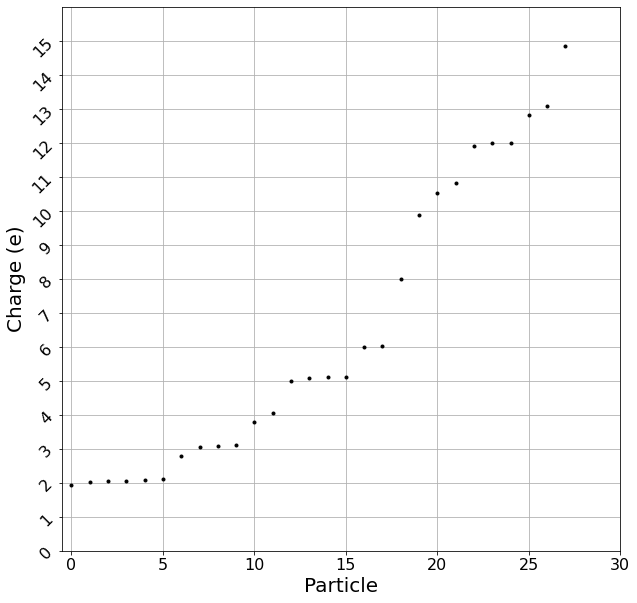

In [72]:
fig = plt.figure(figsize=(10,10))

plt.plot(new_df.num, new_df.q / e, '.k')
plt.errorbar(new_df.num, new_df.q / e, yerr = new_df.q_err, ls='none', c='k')
plt.grid()

plt.ylim(0,16)
plt.xlim(-0.5,30)
plt.yticks(np.arange(0,16,1), fontsize=16)
plt.xticks(fontsize=16)

plt.xlabel('Particle', fontsize=20)
plt.ylabel('Charge (e)', fontsize=20)

ax = fig.gca()
ax.tick_params("y", rotation=45)